In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

In [8]:
import os
import pandas as pd
from PIL import Image
import colorsys

def create_pixel_dataframe(image_folder):
    pixel_data = []
    
    for filename in os.listdir(image_folder):
        if filename.lower().endswith(".png"):
            filepath = os.path.join(image_folder, filename)
            
            try:
                with Image.open(filepath) as img:
                    img = img.convert('RGB')
                    width, height = img.size
                    pixels = img.load()
                    
                    for x in range(width):
                        for y in range(height):
                            r, g, b = pixels[x, y]
                            h, l, s = colorsys.rgb_to_hls(r / 255.0, g / 255.0, b / 255.0)
                            
                            h_deg = round(h * 360, 2)
                            s_pct = round(s * 100, 2)
                            l_pct = round(l * 100, 2)
                            
                            pixel_data.append({
                                'file': filename,
                                'x': x,
                                'y': y,
                                'R': r,
                                'G': g,
                                'B': b,
                                'H': h_deg,
                                'S': s_pct,
                                'L': l_pct
                            })
            except Exception as e:
                print(f"Error processing the file {filename}: {e}")

    return pd.DataFrame(pixel_data)

images_pixels = create_pixel_dataframe("cat-flower")

images_pixels


,file,x,y,R,G,B,H,S,L
0,kwiatek-76.png,0,0,90,99,30,67.83,53.49,25.29
1,kwiatek-76.png,0,1,134,151,26,68.16,70.62,34.71
2,kwiatek-76.png,0,2,132,153,30,70.24,67.21,35.88
3,kwiatek-76.png,0,3,141,158,81,73.25,32.22,46.86
4,kwiatek-76.png,0,4,120,140,36,71.54,59.09,34.51
...,...,...,...,...,...,...,...,...,...
1319995,kwiatek-53.png,99,95,3,3,3,0.00,0.00,1.18
1319996,kwiatek-53.png,99,96,4,4,4,0.00,0.00,1.57
1319997,kwiatek-53.png,99,97,5,5,3,60.00,25.00,1.57
1319998,kwiatek-53.png,99,98,7,10,5,96.00,33.33,2.94


In [9]:
# function to create a color square for visualization
def draw_color_square(row):
    r, g, b = row['R'], row['G'], row['B']
    return f'<div style="width: 25px; height: 25px; background-color: rgb({r}, {g}, {b}); border: 1px solid #000; border-radius: 3px;"></div>'

In [10]:
cats_pixels = images_pixels[images_pixels['file'].str.startswith('kotek')]
unique_colors_cats = cats_pixels.groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count')
unique_colors_cats = unique_colors_cats.reset_index(drop=True)


flowers_pixels = images_pixels[images_pixels['file'].str.startswith('kwiatek')]
unique_colors_flowers = flowers_pixels.groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count')
unique_colors_flowers = unique_colors_flowers.reset_index(drop=True)


max_RGB = unique_colors_cats[['R', 'G', 'B']].max(axis=1)
unique_colors_cats['is_dominating_R'] = (unique_colors_cats['R'] == max_RGB).astype(int)
unique_colors_cats['is_dominating_G'] = (unique_colors_cats['G'] == max_RGB).astype(int)
unique_colors_cats['is_dominating_B'] = (unique_colors_cats['B'] == max_RGB).astype(int)
unique_colors_cats['is_cold'] = ((unique_colors_cats['H'] >= 180) & (unique_colors_cats['H'] <= 270)).astype(int)
unique_colors_cats['is_saturated'] = (unique_colors_cats['S'] > 70).astype(int)

max_RGB = unique_colors_flowers[['R', 'G', 'B']].max(axis=1)
unique_colors_flowers['is_dominating_R'] = (unique_colors_flowers['R'] == max_RGB).astype(int)
unique_colors_flowers['is_dominating_G'] = (unique_colors_flowers['G'] == max_RGB).astype(int)
unique_colors_flowers['is_dominating_B'] = (unique_colors_flowers['B'] == max_RGB).astype(int)
unique_colors_flowers['is_cold'] = ((unique_colors_flowers['H'] >= 180) & (unique_colors_flowers['H'] <= 270)).astype(int)
unique_colors_flowers['is_saturated'] = (unique_colors_flowers['S'] > 70).astype(int)

In [11]:
unique_colors_cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419043 entries, 0 to 419042
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   R                419043 non-null  int64  
 1   G                419043 non-null  int64  
 2   B                419043 non-null  int64  
 3   H                419043 non-null  float64
 4   S                419043 non-null  float64
 5   L                419043 non-null  float64
 6   count            419043 non-null  int64  
 7   is_dominating_R  419043 non-null  int64  
 8   is_dominating_G  419043 non-null  int64  
 9   is_dominating_B  419043 non-null  int64  
 10  is_cold          419043 non-null  int64  
 11  is_saturated     419043 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 38.4 MB


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

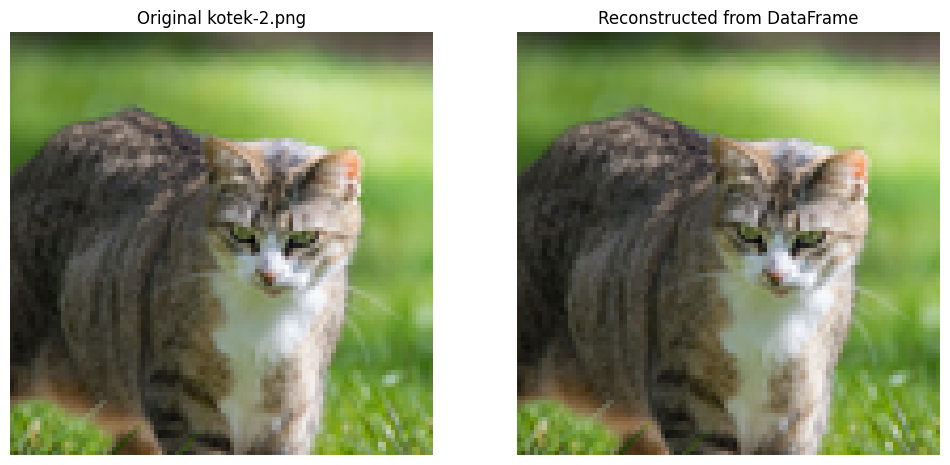

In [12]:
# testing if we can reconstruct the image from the DataFrame
test_image_pixels = images_pixels[images_pixels['file'] == 'kotek-2.png']
width = height = 100
test_image = np.zeros((height, width, 3), dtype=np.uint8)
test_image[test_image_pixels['y'], test_image_pixels['x'], 0] = test_image_pixels['R']
test_image[test_image_pixels['y'], test_image_pixels['x'], 1] = test_image_pixels['G']
test_image[test_image_pixels['y'], test_image_pixels['x'], 2] = test_image_pixels['B']

test_image_photo = Image.open('cat-flower/kotek-2.png').convert('RGB')


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(test_image_photo)
axes[0].set_title(f"Original kotek-2.png")
axes[0].axis('off')

axes[1].imshow(test_image)
axes[1].set_title(f"Reconstructed from DataFrame")
axes[1].axis('off')

Everything is working fine for now
Dataframes from task description are:
a) images_pixels
display(images_pixels.head(10))
b) unique_colors_cats, unique_colors_flowers

In [13]:
# kotek-2.png some colors
# 5 top colors in cats and flowers
test_image_pixels_head = test_image_pixels.head(5).copy()
test_image_pixels_head['color'] = test_image_pixels_head.apply(draw_color_square, axis=1)
display(HTML(test_image_pixels_head.to_html(escape=False)))
unique_colors_cats_head = unique_colors_cats.sort_values('count', ascending=False).head(5).copy()
unique_colors_cats_head['color'] = unique_colors_cats_head.apply(draw_color_square, axis=1)
unique_colors_flowers_head = unique_colors_flowers.sort_values('count', ascending=False).head(5).copy()
unique_colors_flowers_head['color'] = unique_colors_flowers_head.apply(draw_color_square, axis=1)
display(HTML(unique_colors_cats_head.to_html(escape=False)))
display(HTML(unique_colors_flowers_head.to_html(escape=False)))

,file,x,y,R,G,B,H,S,L,color
370000,kotek-2.png,0,0,62,69,45,77.50,21.05,22.35,
370001,kotek-2.png,0,1,67,80,49,85.16,24.03,25.29,
370002,kotek-2.png,0,2,74,90,52,85.26,26.76,27.84,
370003,kotek-2.png,0,3,79,98,57,87.80,26.45,30.39,
370004,kotek-2.png,0,4,85,108,61,89.36,27.81,33.14,


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated,color
419042,255,255,255,0.0,0.00,100.00,538,1,1,1,0,0,
418493,254,254,254,0.0,0.00,99.61,308,1,1,1,0,0,
0,0,0,0,0.0,0.00,0.00,240,1,1,1,0,0,
418238,253,253,253,0.0,0.00,99.22,156,1,1,1,0,0,
416118,246,245,241,48.0,21.74,95.49,78,1,0,0,0,0,


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated,color
0,0,0,0,0.0,0.0,0.00,4462,1,1,1,0,0,
522600,255,255,255,0.0,0.0,100.00,1331,1,1,1,0,0,
217,1,1,1,0.0,0.0,0.39,894,1,1,1,0,0,
502,2,2,2,0.0,0.0,0.78,489,1,1,1,0,0,
729,3,3,3,0.0,0.0,1.18,452,1,1,1,0,0,


In [14]:
# number of unique colors in each image
unique_pixels = images_pixels.drop_duplicates(subset=['file', 'R', 'G', 'B'])

images_colors = unique_pixels.groupby('file').size().reset_index(name='unique_colors')
display(images_colors)
display(images_colors.describe())
display(unique_pixels)

,file,unique_colors
0,kotek-0.png,9177
1,kotek-1.png,9151
2,kotek-10.png,7918
3,kotek-11.png,8913
4,kotek-12.png,9648
...,...,...
127,kwiatek-74.png,5707
128,kwiatek-75.png,9795
129,kwiatek-76.png,9481
130,kwiatek-8.png,7893


,unique_colors
count,132.000000
mean,8649.393939
std,1163.402865
min,4538.000000
25%,7988.000000
50%,9072.500000
75%,9521.250000
max,9911.000000


,file,x,y,R,G,B,H,S,L
0,kwiatek-76.png,0,0,90,99,30,67.83,53.49,25.29
1,kwiatek-76.png,0,1,134,151,26,68.16,70.62,34.71
2,kwiatek-76.png,0,2,132,153,30,70.24,67.21,35.88
3,kwiatek-76.png,0,3,141,158,81,73.25,32.22,46.86
4,kwiatek-76.png,0,4,120,140,36,71.54,59.09,34.51
...,...,...,...,...,...,...,...,...,...
1319953,kwiatek-53.png,99,53,21,32,15,98.82,36.17,9.22
1319954,kwiatek-53.png,99,54,17,27,13,102.86,35.00,7.84
1319982,kwiatek-53.png,99,82,20,22,11,70.91,33.33,6.47
1319984,kwiatek-53.png,99,84,10,12,5,77.14,41.18,3.33


In [15]:
cat_images_color_count = images_colors[images_colors['file'].str.startswith('kotek')]
flowers_images_color_count = images_colors[images_colors['file'].str.startswith('kwiatek')]
print("Flowers:")
display(flowers_images_color_count.describe())

print("Cats:")
display(cat_images_color_count.describe())


Flowers:


,unique_colors
count,77.000000
mean,8251.090909
std,1308.527217
min,4538.000000
25%,7348.000000
50%,8768.000000
75%,9315.000000
max,9881.000000


Cats:


,unique_colors
count,55.000000
mean,9207.018182
std,575.119295
min,7339.000000
25%,8943.000000
50%,9387.000000
75%,9609.000000
max,9911.000000


now i need to comment min, max mean and std of unique colors

In [16]:
# this was partly dode pefore
print("cats:")
display(HTML(unique_colors_cats_head.to_html(escape=False)))
display(unique_colors_cats[['H', 'S', 'L']].describe())
print("flowers:")
display(HTML(unique_colors_flowers_head.to_html(escape=False)))
display(unique_colors_flowers[['H', 'S', 'L']].describe())

cats:


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated,color
419042,255,255,255,0.0,0.00,100.00,538,1,1,1,0,0,
418493,254,254,254,0.0,0.00,99.61,308,1,1,1,0,0,
0,0,0,0,0.0,0.00,0.00,240,1,1,1,0,0,
418238,253,253,253,0.0,0.00,99.22,156,1,1,1,0,0,
416118,246,245,241,48.0,21.74,95.49,78,1,0,0,0,0,


,H,S,L
count,419043.000000,419043.000000,419043.000000
mean,91.889711,33.964362,43.296755
std,65.694036,21.518548,19.448374
min,0.000000,0.000000,0.000000
25%,50.000000,16.740000,29.220000
50%,80.000000,31.090000,41.960000
75%,104.000000,47.220000,55.690000
max,359.150000,100.000000,100.000000


flowers:


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated,color
0,0,0,0,0.0,0.0,0.00,4462,1,1,1,0,0,
522600,255,255,255,0.0,0.0,100.00,1331,1,1,1,0,0,
217,1,1,1,0.0,0.0,0.39,894,1,1,1,0,0,
502,2,2,2,0.0,0.0,0.78,489,1,1,1,0,0,
729,3,3,3,0.0,0.0,1.18,452,1,1,1,0,0,


,H,S,L
count,522601.000000,522601.000000,522601.000000
mean,104.888934,49.862328,42.038394
std,112.129852,28.381060,19.539545
min,0.000000,0.000000,0.000000
25%,32.000000,26.190000,27.250000
50%,61.880000,45.610000,41.370000
75%,105.000000,74.420000,54.900000
max,359.760000,100.000000,100.000000


this i also need to comment

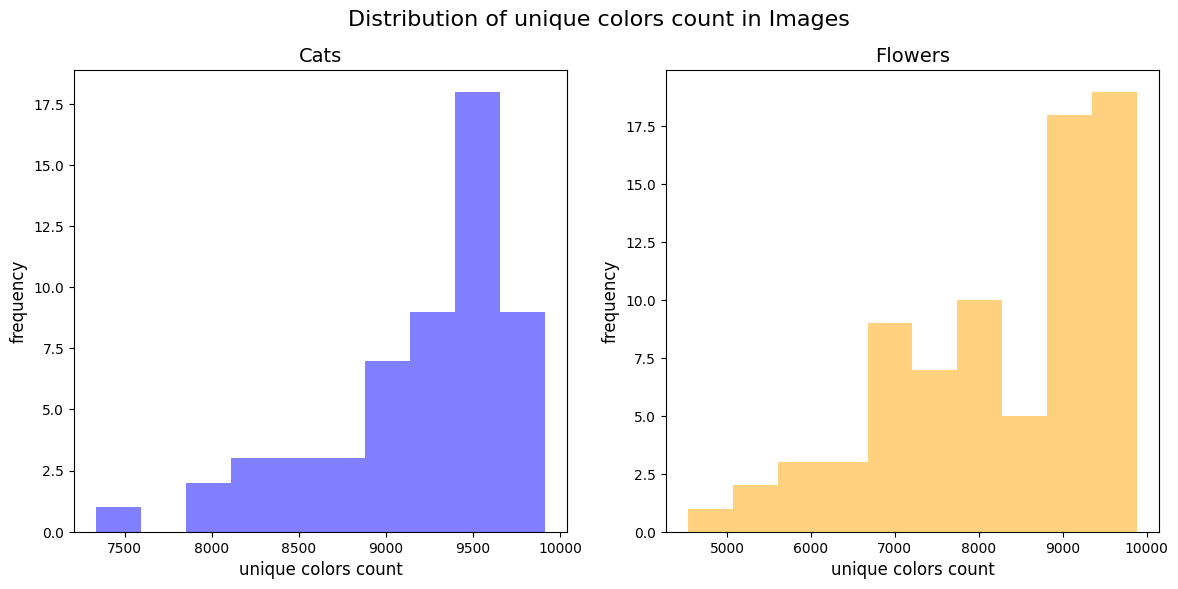

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.hist(cat_images_color_count['unique_colors'], bins=10, alpha=0.5, color='blue')
ax2.hist(flowers_images_color_count['unique_colors'], bins=10, alpha=0.5, color='orange')
ax1.set_title('Cats', fontsize=14)
ax1.set_xlabel('unique colors count', fontsize=12)
ax1.set_ylabel('frequency', fontsize=12)
ax2.set_title('Flowers', fontsize=14)
ax2.set_xlabel('unique colors count', fontsize=12)
ax2.set_ylabel('frequency', fontsize=12)
fig.suptitle('Distribution of unique colors count in Images', fontsize=16)
plt.show()

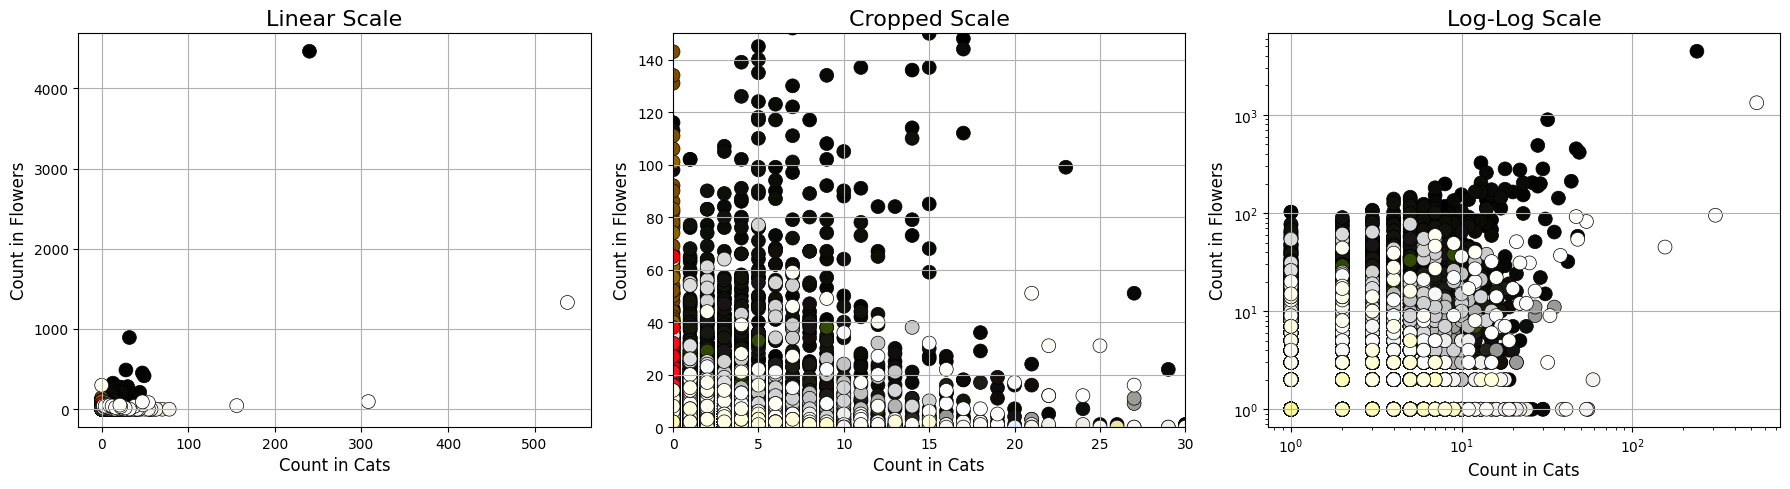

In [18]:
unique_colors_cats_flowers = pd.merge(unique_colors_cats, unique_colors_flowers, on=['R', 'G', 'B'], how='outer', suffixes=('_cats', '_flowers')).fillna(0)
colors_array = unique_colors_cats_flowers[['R', 'G', 'B']].values / 255.0
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(
    unique_colors_cats_flowers['count_cats'],
    unique_colors_cats_flowers['count_flowers'],
    c=colors_array,
    edgecolors='black',
    linewidths=0.5, 
    s=100, 
)
axes[0].set_title('Linear Scale', fontsize=16)
axes[0].set_xlabel('Count in Cats', fontsize=12)
axes[0].set_ylabel('Count in Flowers', fontsize=12)
axes[0].grid(True)

axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 150)
axes[1].scatter(
    unique_colors_cats_flowers['count_cats'],
    unique_colors_cats_flowers['count_flowers'],
    c=colors_array,
    edgecolors='black',
    linewidths=0.5,
    s=100,
)
axes[1].set_title('Cropped Scale', fontsize=16)
axes[1].set_xlabel('Count in Cats', fontsize=12)
axes[1].set_ylabel('Count in Flowers', fontsize=12)
axes[1].grid(True)


axes[2].scatter(
    unique_colors_cats_flowers['count_cats'],
    unique_colors_cats_flowers['count_flowers'],
    c=colors_array,
    edgecolors='black',
    linewidths=0.5,
    s=100,
)
axes[2].set_title('Log-Log Scale', fontsize=16)
axes[2].set_xlabel('Count in Cats', fontsize=12)
axes[2].set_ylabel('Count in Flowers', fontsize=12)
axes[2].grid(True)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

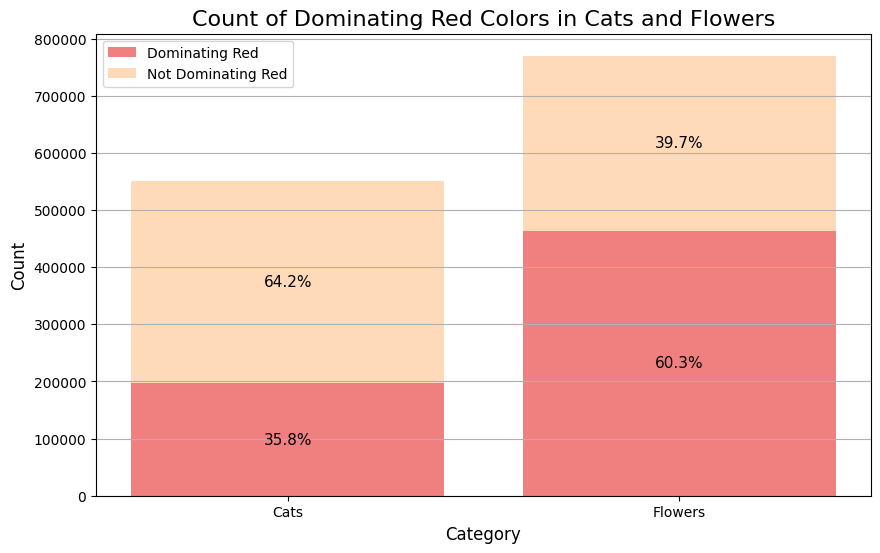

In [ ]:
dom_R_cats = unique_colors_cats[unique_colors_cats['is_dominating_R'] == 1].sum(axis=0)['count']
ndom_R_cats = unique_colors_cats[unique_colors_cats['is_dominating_R'] == 0].sum(axis=0)['count']
dom_R_flowers = unique_colors_flowers[unique_colors_flowers['is_dominating_R'] == 1].sum(axis=0)['count']
ndom_R_flowers = unique_colors_flowers[unique_colors_flowers['is_dominating_R'] == 0].sum(axis=0)['count']

total_cats = dom_R_cats + ndom_R_cats
total_flowers = dom_R_flowers + ndom_R_flowers
totals = [total_cats, total_flowers]

plt.figure(figsize=(10, 6))
bottom = plt.bar(['Cats', 'Flowers'], [dom_R_cats, dom_R_flowers], color='lightcoral', label='Dominating Red')
top = plt.bar(['Cats', 'Flowers'], [ndom_R_cats, ndom_R_flowers], bottom=[dom_R_cats, dom_R_flowers], color='peachpuff', label='Not Dominating Red')
plt.title('Count of Dominating Red Colors in Cats and Flowers', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y')

labels_dom = [f"{(val / tot) * 100:.1f}%" for val, tot in zip([dom_R_cats, dom_R_flowers], totals)]
labels_ndom = [f"{(val / tot) * 100:.1f}%" for val, tot in zip([ndom_R_cats, ndom_R_flowers], totals)]


plt.bar_label(bottom, labels=labels_dom, label_type='center', fontsize=11, color='black')
plt.bar_label(top, labels=labels_ndom, label_type='center', fontsize=11, color='black')
plt.show()

As expected red is more dominating in flowers than in cats (there are more reddish flowers than cats)

In [30]:
import plotly.express as px
sample = unique_colors_cats.sample(50)
rzeczywiste_kolory = sample.apply(lambda row: f'rgb({int(row["R"])}, {int(row["G"])}, {int(row["B"])})', axis=1)
fig = px.scatter_3d(
    sample,
    x='R',
    y='G',
    z='B',
    hover_data=['count']
)
fig.update_traces(marker=dict(color=rzeczywiste_kolory))
fig.update_layout(title='Sample Unique Colors in Cats', scene=dict(xaxis_title='R', yaxis_title='G', zaxis_title='B'))
fig.show()